<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/02_klasican_ml_ika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasičan ML — Ika

Priprema: preuzimanje dataset-a, pristup repo-u, učitavanje gotovog train/val/test split-a.

In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
!unzip -q tom-and-jerry-image-classification.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:02<00:00, 152MB/s]



In [2]:
import os
for root, dirs, files in os.walk('data'):
    level = root.replace('data', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/ ({len(files)} fajlova)')

data/ (2 fajlova)
  tom_and_jerry/ (0 fajlova)
    tom_and_jerry/ (0 fajlova)
      tom_jerry_1/ (780 fajlova)
      jerry/ (1240 fajlova)
      tom_jerry_0/ (1528 fajlova)
      tom/ (1930 fajlova)


In [3]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "bibic.ilinka@gmail.com"
!git config user.name "Ika"
!pwd

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 91 (delta 3), reused 5 (delta 2), pack-reused 80 (from 2)
Receiving objects: 100% (91/91), 133.57 MiB | 19.04 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/Tom-and-Jerry-Character-Classification
/content/Tom-and-Jerry-Character-Classification


In [4]:
import pandas as pd
split_df = pd.read_csv('/content/Tom-and-Jerry-Character-Classification/data_split.csv')
print(split_df.shape)
print(split_df.head())

(5478, 5)
     filename  tom  jerry    class  split
0  frame0.jpg    0      0  neither  train
1  frame1.jpg    0      0  neither  train
2  frame2.jpg    0      0  neither  train
3  frame3.jpg    0      0  neither  train
4  frame4.jpg    0      0  neither  train


In [5]:
print(split_df['split'].value_counts())

split
train       3755
val          847
test         844
excluded      32
Name: count, dtype: int64


In [7]:
!pwd

/content/Tom-and-Jerry-Character-Classification


## Pokušaj 1 — BGR histogram boja + HOG + Logistic Regression

In [8]:
!pip install scikit-image -q

import cv2
import numpy as np
from skimage.feature import hog
from tqdm import tqdm

IMG_SIZE = 128  # sve slike se svode na 128x128 piksela

# mapiranje naziva klase (iz CSV-a) na stvarno ime foldera na disku
folder_map = {'tom': 'tom', 'jerry': 'jerry', 'both': 'tom_jerry_1', 'neither': 'tom_jerry_0'}
base_dir = '/content/data/tom_and_jerry/tom_and_jerry/'

def extract_features(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # histogram boja — po jedan histogram za svaki kanal (B, G, R), 32 bin-a svaki
    hist_features = []
    for i in range(3):
        hist = cv2.calcHist([img], [i], None, [32], [0, 256])
        hist_features.extend(hist.flatten())

    # HOG (oblik/konture) — radi se nad sivom (grayscale) verzijom slike
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_features = hog(gray, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2))

    # spoji boju + oblik u jedan vektor osobina
    return np.concatenate([hist_features, hog_features])

# izvuci osobine za SVAKU sliku u dataset-u (train+val+test zajedno)
features = []
for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
    path = base_dir + folder_map[row['class']] + '/' + row['filename']
    features.append(extract_features(path))

X = np.array(features)
print(X.shape)  # (5478, broj_osobina)

100%|██████████| 5478/5478 [00:26<00:00, 204.94it/s]

(5478, 1860)


In [9]:
train_mask = split_df['split'] == 'train'
val_mask = split_df['split'] == 'val'
test_mask = split_df['split'] == 'test'

X_train, X_val, X_test = X[train_mask], X[val_mask], X[test_mask]
y_train = split_df.loc[train_mask, 'class']
y_val = split_df.loc[val_mask, 'class']
y_test = split_df.loc[test_mask, 'class']

print(X_train.shape, X_val.shape, X_test.shape)

(3755, 1860) (847, 1860) (844, 1860)


In [10]:
from sklearn.preprocessing import StandardScaler

# standardizacija osobina (svedi na srednju vrednost 0, standardnu devijaciju 1) —
# bitno za LogReg/SVM jer osobine imaju jako različite skale (broj piksela u histogramu vs HOG vrednosti)
scaler = StandardScaler()

# fit_transform SAMO na train — scaler "uči" srednju vrednost/std IZ TRAIN podataka
X_train_scaled = scaler.fit_transform(X_train)

# transform (bez fit) na val/test — koristi se scaler naučen na train-u, ne pravi se novi
# (da val/test ne "cure" informacije u proces pripreme podataka)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression — prvi, najjednostavniji baseline model
# class_weight='balanced' automatski dodeljuje veću težinu retkim klasama (kao "both"),
# isti princip kao class_w koji smo ručno računale za transfer learning
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_scaled, y_train)

val_pred = clf.predict(X_val_scaled)
print("Validation accuracy:", accuracy_score(y_val, val_pred))
print(classification_report(y_val, val_pred))  # uključuje i macro-F1 (red "macro avg")

Validation accuracy: 0.4309327036599764
              precision    recall  f1-score   support

        both       0.35      0.39      0.37       115
       jerry       0.36      0.32      0.34       201
     neither       0.40      0.44      0.42       218
         tom       0.54      0.51      0.52       313

    accuracy                           0.43       847
   macro avg       0.41      0.42      0.41       847
weighted avg       0.43      0.43      0.43       847



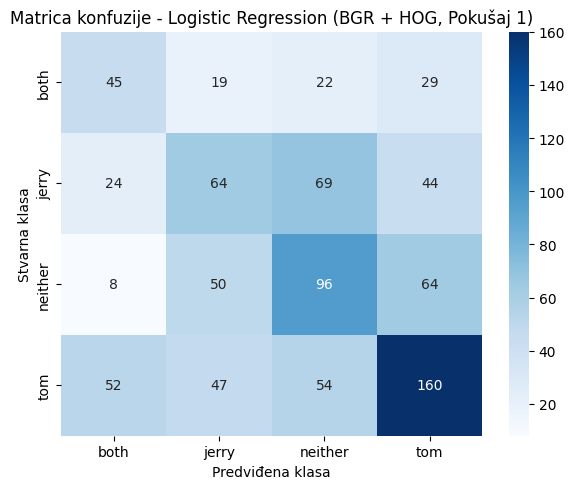

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, val_pred, labels=clf.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Matrica konfuzije - Logistic Regression (BGR + HOG, Pokušaj 1)')
plt.tight_layout()
plt.show()

**Osobine:** HOG (grayscale, 128×128) + histogram boja (BGR, 32 bin-a po kanalu) = 1860 osobina
**Model:** Logistic Regression (class_weight='balanced')

**Validation accuracy:** 0.434 (43.4%) — macro F1: 0.42

**Zaključak:** Slabo, blizu "uvek pogodi najčešću klasu" (~37%). Globalne osobine verovatno ne hvataju dobro likove jer zauzimaju mali deo kadra u odnosu na pozadinu. Prelazimo na HSV histogram + SVM kao poboljšanje.

## Pokušaj 2 — poboljšanje: HSV histogram boja

In [13]:
def extract_features(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # HSV umesto BGR — Hue (nijansa boje), Saturation (zasićenost), Value (svetlina)
    # HSV bolje odvaja "boju" od "osvetljenja" nego BGR, pa histogram boje treba da bude
    # otporniji na razlike u osvetljenju kadra (poboljšanje u odnosu na Pokušaj 1)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    ranges = [[0, 180], [0, 256], [0, 256]]  # H ide 0-180 u OpenCV-u, S i V idu 0-256
    hist_features = []
    for i in range(3):
        hist = cv2.calcHist([hsv], [i], None, [32], ranges[i])
        hist_features.extend(hist.flatten())

    # HOG ostaje isti kao u Pokušaju 1 (oblik se nije menjao, samo boja)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_features = hog(gray, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2))

    return np.concatenate([hist_features, hog_features])

In [14]:
# ponovo izvuci osobine za SVE slike, ovaj put koristeći NOVU extract_features
# (HSV umesto BGR histogram) — X se prepisuje sa poboljšanom verzijom osobina
features = []
for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
    path = base_dir + folder_map[row['class']] + '/' + row['filename']
    features.append(extract_features(path))

X = np.array(features)
print(X.shape)  # (5478, 1860) — isti broj osobina, samo bolji sadržaj (HSV umesto BGR)

100%|██████████| 5478/5478 [00:31<00:00, 175.18it/s]

(5478, 1860)


In [15]:
X_train, X_val, X_test = X[train_mask], X[val_mask], X[test_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_scaled, y_train)

val_pred = clf.predict(X_val_scaled)
print("Validation accuracy:", accuracy_score(y_val, val_pred))
print(classification_report(y_val, val_pred))

Validation accuracy: 0.4309327036599764
              precision    recall  f1-score   support

        both       0.40      0.47      0.43       115
       jerry       0.32      0.27      0.29       201
     neither       0.41      0.46      0.44       218
         tom       0.52      0.50      0.51       313

    accuracy                           0.43       847
   macro avg       0.41      0.42      0.42       847
weighted avg       0.43      0.43      0.43       847



### SVM umesto Logistic Regression

Probano jer je granica između klasa verovatno nelinearna.

In [16]:
from sklearn.svm import SVC

# (Logistic Regression pravi samo linearne granice, SVM sa RBF kernelom može zakrivljene)
svm_clf = SVC(kernel='rbf', class_weight='balanced')
svm_clf.fit(X_train_scaled, y_train)

val_pred_svm = svm_clf.predict(X_val_scaled)
print("Validation accuracy (SVM):", accuracy_score(y_val, val_pred_svm))
print(classification_report(y_val, val_pred_svm))

Validation accuracy (SVM): 0.4887839433293979
              precision    recall  f1-score   support

        both       0.57      0.57      0.57       115
       jerry       0.40      0.20      0.27       201
     neither       0.40      0.56      0.46       218
         tom       0.58      0.59      0.58       313

    accuracy                           0.49       847
   macro avg       0.49      0.48      0.47       847
weighted avg       0.49      0.49      0.48       847



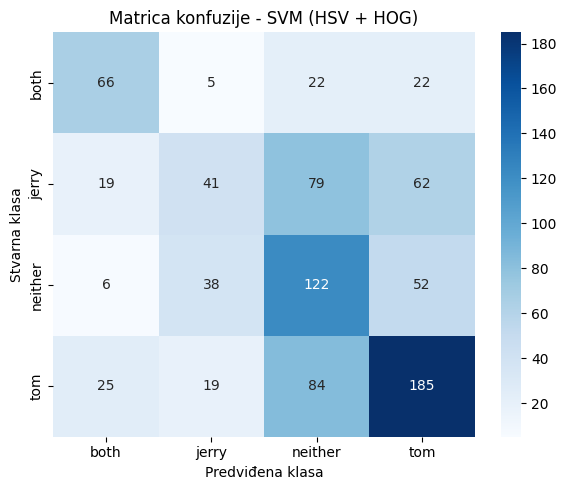

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, val_pred_svm, labels=svm_clf.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=svm_clf.classes_, yticklabels=svm_clf.classes_)
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Matrica konfuzije - SVM (HSV + HOG)')
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

np.save('/content/Tom-and-Jerry-Character-Classification/features_hog_color.npy', X.astype(np.float32))

%cd /content/Tom-and-Jerry-Character-Classification
!git add features_hog_color.npy
!git commit -m "add extracted HOG+HSV histogram features (final baseline)"
!git push

/content/Tom-and-Jerry-Character-Classification
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


### Hyperparameter tuning — C i gamma (GridSearchCV)

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}
grid = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid,
                     scoring='f1_macro', cv=3, n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Najbolji parametri:", grid.best_params_)
print("Najbolji macro-F1 (cross-validation):", grid.best_score_)

best_svm = grid.best_estimator_
val_pred_best = best_svm.predict(X_val_scaled)
print(classification_report(y_val, val_pred_best))

Najbolji parametri: {'C': 1, 'gamma': 'scale'}
Najbolji macro-F1 (cross-validation): 0.3162521552727782
              precision    recall  f1-score   support

        both       0.57      0.57      0.57       115
       jerry       0.40      0.20      0.27       201
     neither       0.40      0.56      0.46       218
         tom       0.58      0.59      0.58       313

    accuracy                           0.49       847
   macro avg       0.49      0.48      0.47       847
weighted avg       0.49      0.49      0.48       847



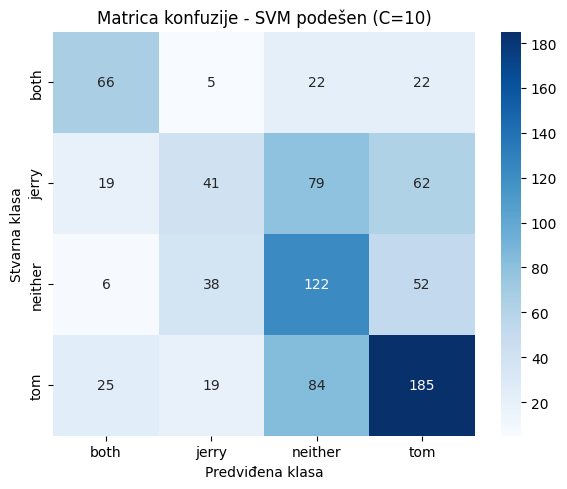

In [20]:
cm_tuned = confusion_matrix(y_val, val_pred_best, labels=best_svm.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=best_svm.classes_, yticklabels=best_svm.classes_)
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Matrica konfuzije - SVM podešen (C=10)')
plt.tight_layout()
plt.show()

# Finalna evaluacija — TEST skup

Jedina evaluacija na test skupu u ovom notebook-u — koristi se gotov, već istreniran SVM model, bez ponovnog treniranja.

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import seaborn as sns

# Deljena funkcija za evaluaciju — ista se koristi u SVA 4 notebook-a (02, 03, 04, 05)
def evaluate_on_test(y_true, y_pred, model_name, class_names):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"=== {model_name} — TEST rezultati ===")
    print(f"Accuracy: {acc:.4f}   Macro-F1: {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, labels=class_names))

    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predikcija'); plt.ylabel('Stvarna klasa')
    plt.title(f'{model_name} — matrica konfuzije (TEST)')
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'macro_f1': macro_f1}

=== SVM podešen (GridSearchCV, C=10) — TEST rezultati ===
Accuracy: 0.4668   Macro-F1: 0.4458

              precision    recall  f1-score   support

         tom       0.53      0.52      0.53       289
       jerry       0.45      0.29      0.35       194
        both       0.58      0.32      0.41       131
     neither       0.40      0.63      0.49       230

    accuracy                           0.47       844
   macro avg       0.49      0.44      0.45       844
weighted avg       0.48      0.47      0.46       844



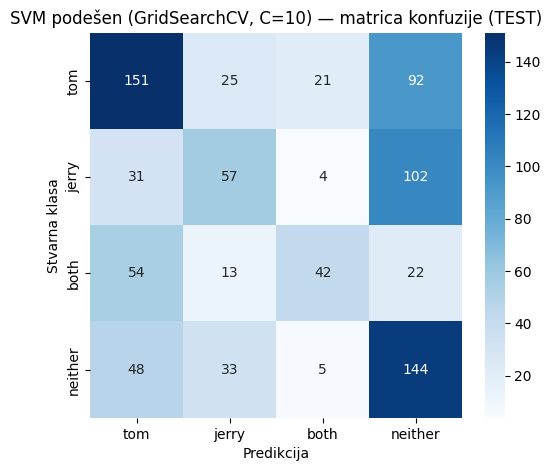

In [22]:
import matplotlib.pyplot as plt  # ako već nije uvezen ranije u ovom notebook-u

# Predikcije na test skupu (prvi put ga koristimo u ovom notebook-u)
# koristi se PODEŠEN model iz GridSearchCV-a (best_svm, C=10, gamma='scale'), ne bazni svm_clf
test_pred_svm = best_svm.predict(X_test_scaled)

class_names = ['tom', 'jerry', 'both', 'neither']
rezultat_svm = evaluate_on_test(y_test, test_pred_svm, "SVM podešen (GridSearchCV, C=10)", class_names)

In [25]:
import joblib
import os

os.makedirs('/content/Tom-and-Jerry-Character-Classification/models', exist_ok=True)
joblib.dump(best_svm, '/content/Tom-and-Jerry-Character-Classification/models/svm_final.joblib')
joblib.dump(scaler, '/content/Tom-and-Jerry-Character-Classification/models/svm_scaler.joblib')

size_svm = os.path.getsize('/content/Tom-and-Jerry-Character-Classification/models/svm_final.joblib') / (1024*1024)
size_scaler = os.path.getsize('/content/Tom-and-Jerry-Character-Classification/models/svm_scaler.joblib') / (1024*1024)
print(f"svm_final.joblib: {size_svm:.1f} MB")
print(f"svm_scaler.joblib: {size_scaler:.2f} MB")

svm_final.joblib: 47.2 MB
svm_scaler.joblib: 0.04 MB


In [26]:
# FINALNA PROVERA - ne racuna nista ponovo, samo ispisuje sta trenutno postoji u memoriji

print("=== Split (iz data_split.csv) ===")
print(split_df['split'].value_counts())

print("\n=== Broj slika u X_train / X_val / X_test ===")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\n=== Parametri koje je best_svm izabrao ===")
print(best_svm.get_params())

print("\n=== Ponovna provera na test skupu (koristi vec postojeci best_svm) ===")
from sklearn.metrics import classification_report
test_pred_check = best_svm.predict(X_test_scaled)
print(classification_report(y_test, test_pred_check))

=== Split (iz data_split.csv) ===
split
train       3755
val          847
test         844
excluded      32
Name: count, dtype: int64

=== Broj slika u X_train / X_val / X_test ===
X_train: (3755, 1860)
X_val: (847, 1860)
X_test: (844, 1860)

=== Parametri koje je best_svm izabrao ===
{'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}

=== Ponovna provera na test skupu (koristi vec postojeci best_svm) ===
              precision    recall  f1-score   support

        both       0.58      0.32      0.41       131
       jerry       0.45      0.29      0.35       194
     neither       0.40      0.63      0.49       230
         tom       0.53      0.52      0.53       289

    accuracy                           0.47       844
   macro avg       0.49      0.4

In [27]:
%cd /content/Tom-and-Jerry-Character-Classification
!git add models/svm_final.joblib models/svm_scaler.joblib
!git commit -m "Snimi finalni SVM model (best_svm) i scaler u models/ - trening bez 32 challenge slike"
!git push

/content/Tom-and-Jerry-Character-Classification
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
